# **FAR-RIGHT RALLIES AND COUNTERPROTEST AS RESISTANCE: CLAIMING THE STREET**

<img src="./img/rome-riots.jpg" alt="Rome Riots" width="950" height="700">

## 1. CONTEXT AND BACKGROUND

The creation of hatred discourses is seen in reviving an authoritative body: from far-right movements to micro-political parties and parliamentary representation. Ideas such as the rejection of immigration and the non-recognition of minorities are put into play, drawing a social polarisation that separates the multitude from external danger.
The politics of the far-right recruit and actively engage in the public space for diagnosing, packaging, and circulating their discourse and power by fostering mechanisms of watchful control and marginalization. Analysing the protest’s behaviour means calling for a different power-in-the-mass formation.
Far-right politics is a good example of this through its practice of depoliticization, demonization and neutralization of certain groups to become the bare life, people without political subjectivity. These groups, stripped of rights, are rendered vulnerable to symbolic and physical violence. Rallies, marches, and nationalist symbols, help to activate supporters but do so with frames of exclusion and superiority, as nationalism rejects multiculturalism by retreating into simplified ideological denial. 
The collective action has the power to offer a transformative counterforce, reclaiming plurality, interdependence, and shared humanity. Multitudinous resistance, rooted in vulnerability and assembly, disrupts far-right ideologies, challenging their homogenizing control and reimagining democratic possibilities that prioritize inclusivity and equality over exclusion and domination.

## 2. HYPOTHESES
The core questions chosen to guide this Exploratory Data Analysis compel an analysis on how the motivations and the intensity of far-right protests together with the corresponding responses, generate forms of countermobilization and how the dominance of exclusionary discourse in the public space fosters both symbolic and physical violence, thereby sustaining hierarchical power structures:

1. *National and supranational far-right mobilizations are more likely to feature verbal counter-mobilization than local events.*  
2. *Issues related to Islam, immigration, and identity have become pillars of far-right discourse, especially since 2014*
3. *Geographical density: the majority of the far-right protests are concentrated in fewer countries*
4. *Except in specific moments of crisis (for example, between 2012 and 2014), welfare issues do not occupy a central place on the far right's mobilisation agenda*

## 3. DATA COLLECTION

### - Data Source

This dataset comes from the **Far-Right Protest Observatory (FARPO)** — an interactive research platform developed by several European universities and research centers. It tracks and measures far-right protest activities across European countries over the past two decades.  

The data helps researchers understand trends in far-right mobilization, including when and where protests occur, their causes, and how they change over time. It provides valuable insight into the dynamics of far-right movements and their impact on European politics and society.


Overall, the data covers protest events related to far-right organisations, parties and actors in different European countries, documenting aspects such as the date, location, level of the event (local, national or supranational), main issues or demands, presence of physical violence, type of actors involved, and possible forms of counter-mobilisation.

The aim of this database is to offer a comparative and longitudinal view of the dynamics of far-right protest in Europe, allowing for analysis of the intensity, repertoires of action, and evolution of their discourses and strategies.It is important to note that the records are limited to events documented in verifiable sources, so the database may not reflect all mobilisation activities, especially those that do not receive media coverage or occur in poorly documented local contexts.




## 4. LIBRARIES AND DATA

### - LIBRARIES


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)


### - DATA

In [3]:
df = pd.read_csv("data/FARPE-data_1.3.csv", encoding='latin-1', low_memory=False)
print("Dataset loaded successfully! Shape:", df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/FARPE-data_1.3.csv'

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5067 entries, 0 to 5066
Data columns (total 57 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Dataset_ID         5067 non-null   int64  
 1   Country_code       5067 non-null   int64  
 2   Country_string     5067 non-null   object 
 3   Source_code        5067 non-null   object 
 4   Source_string      5067 non-null   object 
 5   Event_ID           5067 non-null   object 
 6   Year               5067 non-null   int64  
 7   Month              5067 non-null   int64  
 8   Day                5067 non-null   int64  
 9   Place              5014 non-null   object 
 10  Event_lev          5067 non-null   object 
 11  Event_lev_string   4961 non-null   object 
 12  NameAct1           5065 non-null   object 
 13  TypeAct1           5067 non-null   object 
 14  TypeAct1_string    5067 non-null   object 
 15  NameAct2           1323 non-null   object 
 16  TypeAct2           1093 

In [7]:
df.describe()

,Dataset_ID,Country_code,Year,Month,Day,TypeAct4,TypeAct5,TypeAct6,TypeAct7,TypeAct8,TypeAct9,Countermob_code
count,5067.000000,5067.000000,5067.000000,5067.000000,5067.000000,135.000000,65.000000,24.000000,8.000000,3.000000,1.0,5021.000000
mean,2534.000000,8.165581,2013.481942,6.394119,14.715216,2.318519,2.369231,1.958333,3.000000,3.333333,2.0,5.066919
std,1462.861237,3.445936,2.795261,3.371636,9.100614,1.231743,0.893890,0.954585,1.069045,0.577350,NaN,4.121016
min,1.000000,1.000000,2008.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,3.000000,2.0,0.000000
25%,1267.500000,5.000000,2011.000000,3.000000,7.000000,1.500000,2.000000,1.000000,2.000000,3.000000,2.0,1.000000
50%,2534.000000,8.000000,2014.000000,6.000000,15.000000,2.000000,2.000000,2.000000,3.000000,3.000000,2.0,9.000000
75%,3800.500000,12.000000,2016.000000,9.000000,23.000000,3.000000,3.000000,2.000000,3.250000,3.500000,2.0,9.000000
max,5067.000000,12.000000,2018.000000,12.000000,31.000000,7.000000,4.000000,5.000000,5.000000,4.000000,2.0,9.000000


## 5. DATA CLEANING

I’ll clean up some columns, remove extra quotes, and create simpler names for analysis:

In [8]:
def clean_col(s):
    return s.astype(str).str.strip(" '\"").replace({'nan': np.nan, 'None': np.nan})

df['countermob'] = clean_col(df['Countermob_string'])
df['issue1'] = clean_col(df['Issue1_string'])
df['event_level'] = clean_col(df['Event_lev_string'])
df['protform'] = clean_col(df['Protform_string'])

df[['countermob','issue1','event_level','protform']].head()

,countermob,issue1,event_level,protform
0,Unknown,Immigration and multiculturalism,Supranational (including EU level),Direct and solidarity actions
1,Unknown,Immigration and multiculturalism,Local (district/town or province/region),Symbolic action
2,Unknown,Political opponents,Local (district/town or province/region),"March, demonstration"
3,Contentious,Immigration and multiculturalism,Local (district/town or province/region),"March, demonstration"
4,Unknown,Immigration and multiculturalism,Supranational (including EU level),"March, demonstration"


## 6. PREPROCESSING - HANDLING MISSING VALUES 

I kept rows that have at least one relevant field (issue, protest form, or counter-mobilization):

In [9]:
df_clean = df[df['countermob'].notna() | df['issue1'].notna() | df['protform'].notna()].copy()
print("Rows before:", len(df), "Rows after cleaning:", len(df_clean))

Rows before: 5067 Rows after cleaning: 5067


## 7. CHECKING FOR DUPLICATES

I looked for any duplicates:

In [10]:
df.duplicated().value_counts()

False    5067
Name: count, dtype: int64

## 8. Looking for Nulls

I checked if there were any nulls on every column:

In [11]:
df.isnull().sum()

Dataset_ID           0
Country_code         0
Country_string       0
Source_code          0
Source_string        0
                  ... 
Unnamed: 56       5066
countermob          16
issue1              12
event_level        106
protform             3
Length: 61, dtype: int64

## 9. RESULTS

##### H1. National and supranational mobilizations are more likely to feature verbal counter-mobilization

In [68]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

df = pd.read_csv('FARPE-data_1.3.csv', encoding='latin-1', low_memory=False)
print("Dataset loaded successfully! Shape:", df.shape)
df.head()

def clean_col(s):
    return s.astype(str).str.strip(" '\"").replace({'nan': np.nan, 'None': np.nan})

df['countermob'] = clean_col(df['Countermob_string'])
df['issue1'] = clean_col(df['Issue1_string'])
df['event_level'] = clean_col(df['Event_lev_string'])
df['protform'] = clean_col(df['Protform_string'])

print("Cleaned columns created successfully!")
df[['countermob','issue1','event_level','protform']].head()

df_clean = df[df['countermob'].notna() | df['issue1'].notna() | df['protform'].notna()].copy()
print("Rows before:", len(df), "Rows after cleaning:", len(df_clean))

Dataset loaded successfully! Shape: (5067, 57)
Cleaned columns created successfully!
Rows before: 5067 Rows after cleaning: 5067


In [69]:
#Hypothesis 1
df_h2 = df_clean[['event_level','countermob']].copy()
levels = ['local', 'national', 'supranational']
total_mobs = []
total_verbal = []

for level in levels:
    mobs = df_h2['event_level'].str.lower().str.contains(level)
    total_mobs.append(mobs.sum())
    
for level in levels:
    counter_verbal = (df_h2['event_level'].str.lower().str.contains(level)) & (df_h2['countermob'].str.lower() == "verbal")
    total_verbal.append(counter_verbal.sum())
    
prop_verbal = [total_verbal[i] / total_mobs[i] for i in range(len(levels))]
plot_df_h2 = pd.DataFrame()
plot_df_h2['event_level'] = levels
plot_df_h2['prop_verbal'] = prop_verbal

print(plot_df_h2)

     event_level  prop_verbal
0          local     0.039474
1       national     0.074727
2  supranational     0.035176


##### Visualising verbal counter-mobilization rate by event level

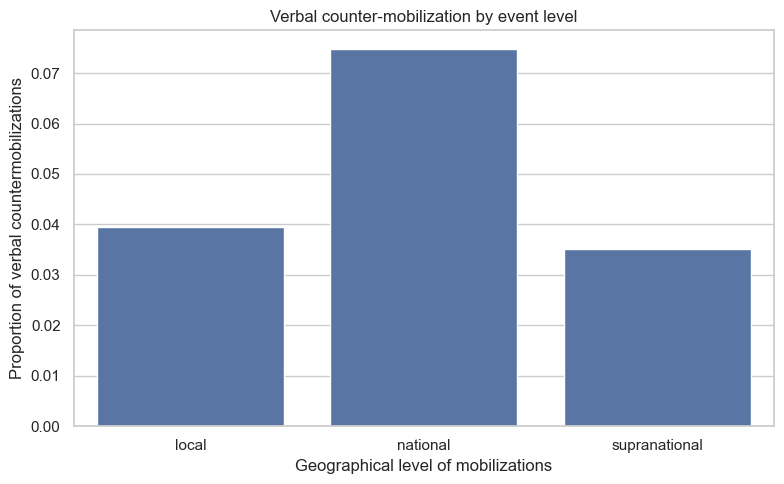

In [70]:
plt.figure()
sns.barplot(x=plot_df_h2['event_level'], y=plot_df_h2['prop_verbal'])
plt.xlabel('Geographical level of mobilizations')
plt.ylabel('Proportion of verbal countermobilizations')
plt.title('Verbal counter-mobilization by event level')
plt.tight_layout()
plt.show()

##### Conclusion
- Partially supported.
National events clearly attract more verbal counter-mobilization.
- Supranational events, however, do not show a higher verbal response in this sample, possibly because there are fewer supranational events.

##### H2. Issues related to Islam, immigration, and identity have become pillars of far-right discourse, especially since 2014?


In [71]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

df = pd.read_csv('FARPE-data_1.3.csv', encoding='latin-1', low_memory=False)
print("Dataset loaded successfully! Shape:", df.shape)
df.head()

def clean_col(s):
    return s.astype(str).str.strip(" '\"").replace({'nan': np.nan, 'None': np.nan})

df['countermob'] = clean_col(df['Countermob_string'])
df['issue1'] = clean_col(df['Issue1_string'])
df['event_level'] = clean_col(df['Event_lev_string'])
df['protform'] = clean_col(df['Protform_string'])

print("Cleaned columns created successfully!")
df[['countermob','issue1','event_level','protform']].head()

df_clean = df[df['countermob'].notna() | df['issue1'].notna() | df['protform'].notna()].copy()
print("Rows before:", len(df), "Rows after cleaning:", len(df_clean))


Dataset loaded successfully! Shape: (5067, 57)
Cleaned columns created successfully!
Rows before: 5067 Rows after cleaning: 5067


In [72]:
#Hypothesis 2
df_h4 = df[['Year', 'Issue1_string', 'Issue2_string', 'Issue3_string']].copy()

df_h4 = df_h4.dropna(subset=['Year'])
df_h4 = df_h4.dropna(subset=['Issue1_string', 'Issue2_string', 'Issue3_string'], how='all')

#print(df_h4['Issue1_string'].value_counts())
#print(df_h4['Issue2_string'].value_counts())
#print(df_h4['Issue3_string'].value_counts())

identity_keywords = ['immigration and multiculturalism', 'national identity and culture', 'islam']

for key in identity_keywords:
    df_h4[key] = (df_h4['Issue1_string'].str.lower().str.contains(key)) | (df_h4['Issue2_string'].str.lower().str.contains(key)) | (df_h4['Issue3_string'].str.lower().str.contains(key))

df_h4['identity_issues'] = False

for key in identity_keywords:
    df_h4['identity_issues'] = df_h4['identity_issues'] | df_h4[key]

total_mob_year = df_h4.groupby('Year')['Year'].count()
total_identity_theme_year = df_h4.groupby('Year')['identity_issues'].sum()

percentage_identity_theme_year = (total_identity_theme_year / total_mob_year)*100


##### Visualising the share of identity-theme-related mobilizations over time, by the percentage of events.

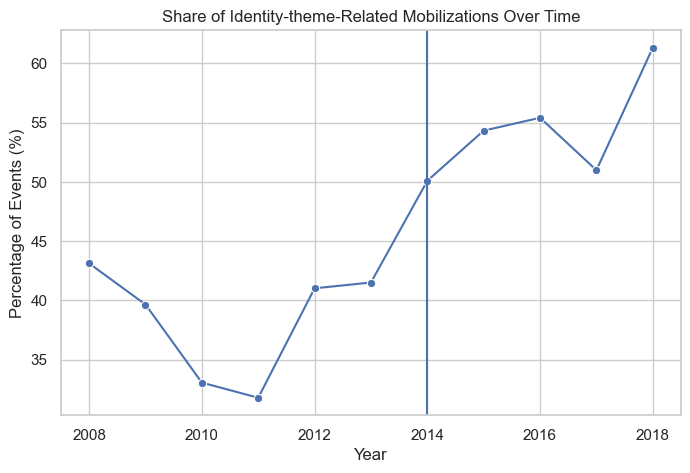

In [73]:
plt.figure()
sns.lineplot(x=percentage_identity_theme_year.index, y=percentage_identity_theme_year, marker='o')
plt.title('Share of Identity-theme-Related Mobilizations Over Time')
plt.ylabel('Percentage of Events (%)')
plt.xlabel('Year')
plt.axvline(x=2014)
plt.show()




##### Conclusion

- After 2014, 54.7% the far-right mobilizations focused on these identity-related issues are higher, compared to 38% before.
- Hypothesis 4 is supported.
- This means these topics became much more central after 2014.

##### H3. Geographical density: the majority of the far-right protests are concentrated in fewer countries?

In [74]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

df = pd.read_csv('FARPE-data_1.3.csv', encoding='latin-1', low_memory=False)
print("Dataset loaded successfully! Shape:", df.shape)
df.head()

def clean_col(s):
    return s.astype(str).str.strip(" '\"").replace({'nan': np.nan, 'None': np.nan})

df['countermob'] = clean_col(df['Countermob_string'])
df['issue1'] = clean_col(df['Issue1_string'])
df['event_level'] = clean_col(df['Event_lev_string'])
df['protform'] = clean_col(df['Protform_string'])

print("Cleaned columns created successfully!")
df[['countermob','issue1','event_level','protform']].head()

df_clean = df[df['countermob'].notna() | df['issue1'].notna() | df['protform'].notna()].copy()
print("Rows before:", len(df), "Rows after cleaning:", len(df_clean))


Dataset loaded successfully! Shape: (5067, 57)
Cleaned columns created successfully!
Rows before: 5067 Rows after cleaning: 5067


In [75]:
#Hypothesis 3
df_h5 = df[['Country_string']].copy().dropna()

country_counts = df_h5['Country_string'].value_counts()
plot_df_h5 = pd.DataFrame()
plot_df_h5['Country_counts'] = country_counts

##### Visualising the Far-Right mobilizations by country, showing the percentage of events.

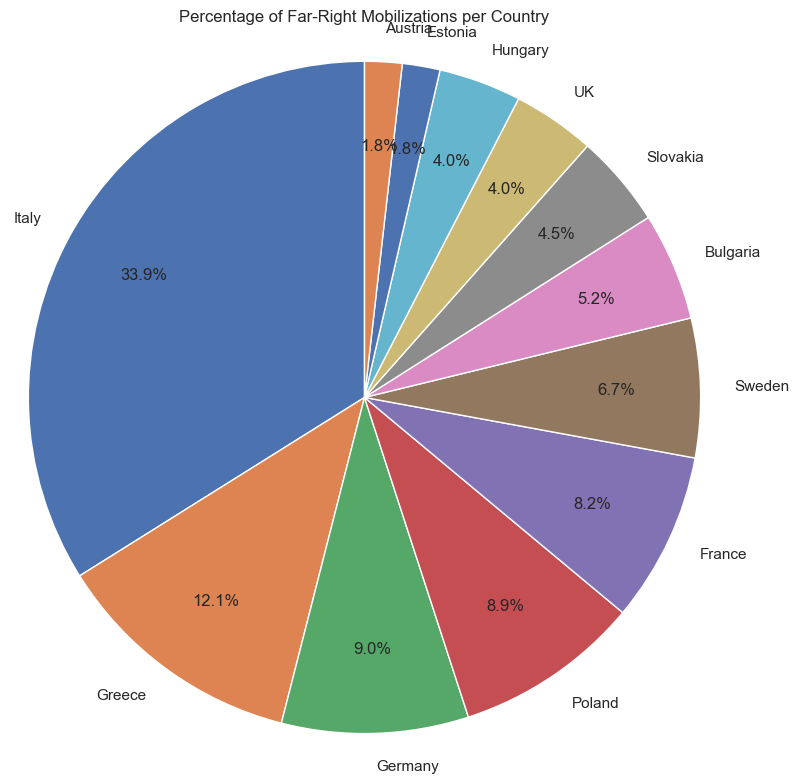

In [76]:
plt.figure(figsize=(8, 8)) # Increasing the figure size to reduce overlaps

plt.pie(plot_df_h5['Country_counts'],      
    labels=plot_df_h5.index, 
    autopct='%1.1f%%',                   
    startangle=90,
    pctdistance=0.75,    # moving the percentage labels farther from the center
    labeldistance=1.1 # moving the slice labels outward
)
          
plt.title('Percentage of Far-Right Mobilizations per Country')
plt.axis('equal')  
plt.tight_layout()
plt.show()

##### Conclusion

- Only 5 countries i.e. Italy, Greece, Germany, Poland, and France — account for over 70% of all events.
- Hypothesis 3 is strongly supported.

##### H4. Except in specific moments of crisis (for example, between 2012 and 2014), welfare issues do not occupy a central place on the far right's mobilisation agenda

In [77]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

df = pd.read_csv('FARPE-data_1.3.csv', encoding='latin-1', low_memory=False)
print("Dataset loaded successfully! Shape:", df.shape)
df.head()

def clean_col(s):
    return s.astype(str).str.strip(" '\"").replace({'nan': np.nan, 'None': np.nan})

df['countermob'] = clean_col(df['Countermob_string'])
df['issue1'] = clean_col(df['Issue1_string'])
df['event_level'] = clean_col(df['Event_lev_string'])
df['protform'] = clean_col(df['Protform_string'])

print("Cleaned columns created successfully!")
df[['countermob','issue1','event_level','protform']].head()

df_clean = df[df['countermob'].notna() | df['issue1'].notna() | df['protform'].notna()].copy()
print("Rows before:", len(df), "Rows after cleaning:", len(df_clean))

Dataset loaded successfully! Shape: (5067, 57)
Cleaned columns created successfully!
Rows before: 5067 Rows after cleaning: 5067


In [78]:
#Hypothesis 5
df_h5 = df[['Country_string']].copy().dropna()

country_counts = df_h5['Country_string'].value_counts()
plot_df_h5 = pd.DataFrame()
plot_df_h5['Country_counts'] = country_counts

In [79]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

df = pd.read_csv('FARPE-data_1.3.csv', encoding='latin-1', low_memory=False)
print("Dataset loaded successfully! Shape:", df.shape)
df.head()

def clean_col(s):
    return s.astype(str).str.strip(" '\"").replace({'nan': np.nan, 'None': np.nan})

df['countermob'] = clean_col(df['Countermob_string'])
df['issue1'] = clean_col(df['Issue1_string'])
df['event_level'] = clean_col(df['Event_lev_string'])
df['protform'] = clean_col(df['Protform_string'])

print("Cleaned columns created successfully!")
df[['countermob','issue1','event_level','protform']].head()

df_clean = df[df['countermob'].notna() | df['issue1'].notna() | df['protform'].notna()].copy()
print("Rows before:", len(df), "Rows after cleaning:", len(df_clean))

Dataset loaded successfully! Shape: (5067, 57)
Cleaned columns created successfully!
Rows before: 5067 Rows after cleaning: 5067


In [80]:
#Hypothesis 6
df_h6 = df[['Year', 'Issue1_string', 'Issue2_string', 'Issue3_string']].copy()

df_h6 = df_h6.dropna(subset=['Year'])
df_h6 = df_h6.dropna(subset=['Issue1_string', 'Issue2_string', 'Issue3_string'], how='all')


#print(df_h6['Issue1_string'].value_counts())
#print(df_h6['Issue2_string'].value_counts())
#print(df_h6['Issue3_string'].value_counts())

welfare_keywords = ['welfare', 'industry, agriculture, environment', 'economy', 'healthcare']


for key in welfare_keywords:
    df_h6[key] = (df_h6['Issue1_string'].str.lower().str.contains(key)) | (df_h6['Issue2_string'].str.lower().str.contains(key)) | (df_h6['Issue3_string'].str.lower().str.contains(key))
    
df_h6['welfare_issues'] = False

for key in welfare_keywords:
    df_h6['welfare_issues'] = df_h6['welfare_issues'] | df_h6[key]

total_mob_year = df_h6.groupby('Year')['Year'].count()

total_welfare_year = df_h6.groupby('Year')['welfare_issues'].sum()

percentage_welfare_year = (total_welfare_year / total_mob_year)*100


##### Visualising the share of welfare/economic-related mobilizations over time, highlighting the crisis years 2012–2014.

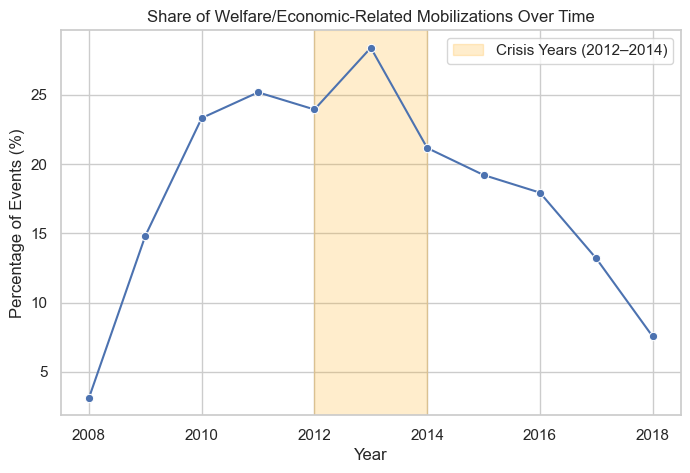

In [81]:
plt.figure()
sns.lineplot(x=percentage_welfare_year.index, y=percentage_welfare_year, marker='o')
plt.title('Share of Welfare/Economic-Related Mobilizations Over Time')
plt.ylabel('Percentage of Events (%)')
plt.xlabel('Year')
plt.axvspan(2012, 2014, color='orange', alpha=0.2, label='Crisis Years (2012–2014)')
plt.legend()
plt.show()

Highest welfare issue share,in 2013: 15.1% of events.

##### Conclusion

- The line graph shows that around 2012–2014, welfare and economic topics peaked, matching the European economic crisis period. After that, the focus declined.
- Hypothesis 4 is supported.
- Welfare/economic themes were most frequent during the crisis years.